In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
df=pd.read_excel("TITANIC DATA.xlsx")

In [6]:
df[:2]

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1


---


In [7]:
#null values
df.isnull().sum()

PassengerId      0
Name             0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

In [8]:
#information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.shape

(891, 12)

---

In [10]:
df[:5]

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [11]:
#reducing columns

df.drop(columns=["PassengerId","Name","Ticket","Cabin"],inplace=True)

In [12]:
df.shape

(891, 8)

---

In [13]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

In [14]:
df.Age.mean(),df.Age.median(),df.Age.min(),df.Age.max()

(np.float64(29.69911764705882),
 np.float64(28.0),
 np.float64(0.42),
 np.float64(80.0))

In [15]:
df.Age=df.Age.fillna(30)

In [16]:
df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Survived    0
dtype: int64

In [17]:
df=df.dropna()

In [18]:
df.shape

(889, 8)

---

In [19]:
df[:3]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1


In [20]:
# distribution of passenger class

df.Pclass.value_counts()

Pclass
3    491
1    214
2    184
Name: count, dtype: int64

---

In [21]:
df.Age.min(),df.Age.mean(),df.Age.max()

(np.float64(0.42), np.float64(29.713352080989875), np.float64(80.0))

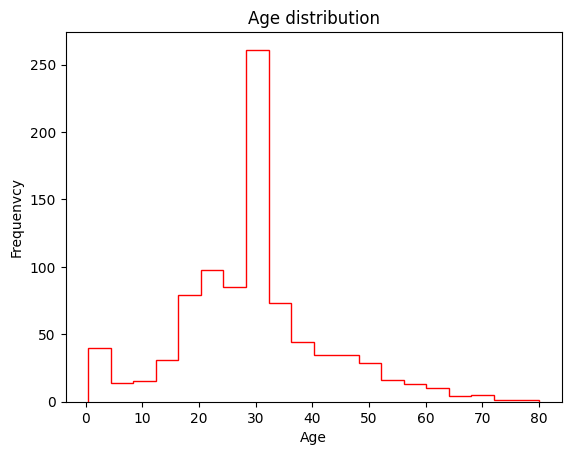

In [ ]:
plt.Figure(figsize=(16,4))
plt.hist(df.Age,bins=20,color="red",histtype="step")
plt.xlabel("Age")
plt.ylabel("Frequenvcy")
plt.title("Age distribution")
plt.show()

In [ ]:
df["Age Category"]=pd.cut(df.Age,bins=[0,15,30,60,81],labels=["Teens","Youth","Adult","Senior Citizens"],include_lowest=True)

In [24]:
df[:2]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,22.0,1,0,7.2500,S,0,Youth
1,1,female,38.0,1,0,71.2833,C,1,Adult


In [25]:
df=df.drop("Age",axis=1)

In [26]:
df[:2]

,Pclass,Sex,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,1,0,7.2500,S,0,Youth
1,1,female,1,0,71.2833,C,1,Adult


---

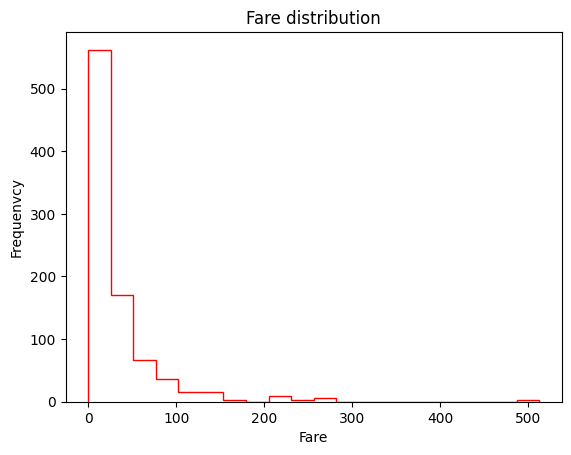

In [27]:
plt.Figure(figsize=(16,4))

plt.hist(df.Fare,bins=20,color="red",histtype="step")
plt.xlabel("Fare")
plt.ylabel("Frequenvcy")
plt.title("Fare distribution")
plt.show()

In [28]:
df["Fare Category"]=pd.cut(df.Fare,bins=[0,100,200,400,520],labels=["Low","Medium","High","Expensive"],include_lowest=True)

In [29]:
df=df.drop("Fare",axis=1)

In [30]:
df[:2]

,Pclass,Sex,SibSp,Parch,Embarked,Survived,Age Category,Fare Category
0,3,male,1,0,S,0,Youth,Low
1,1,female,1,0,C,1,Adult,Low


---

In [31]:
# Analyzing siblingspouse

df.SibSp.min(),df.SibSp.max()

(np.int64(0), np.int64(8))

In [32]:
# Analyzing Parch

df.Parch.min(),df.Parch.max()

(np.int64(0), np.int64(6))

In [33]:
df["Family"]=df.SibSp + df.Parch

In [34]:
df[:2]

,Pclass,Sex,SibSp,Parch,Embarked,Survived,Age Category,Fare Category,Family
0,3,male,1,0,S,0,Youth,Low,1
1,1,female,1,0,C,1,Adult,Low,1


In [35]:
df=df.drop("SibSp",axis=1)

In [36]:
df=df.drop("Parch",axis=1)

In [37]:
df[:2]

,Pclass,Sex,Embarked,Survived,Age Category,Fare Category,Family
0,3,male,S,0,Youth,Low,1
1,1,female,C,1,Adult,Low,1


---

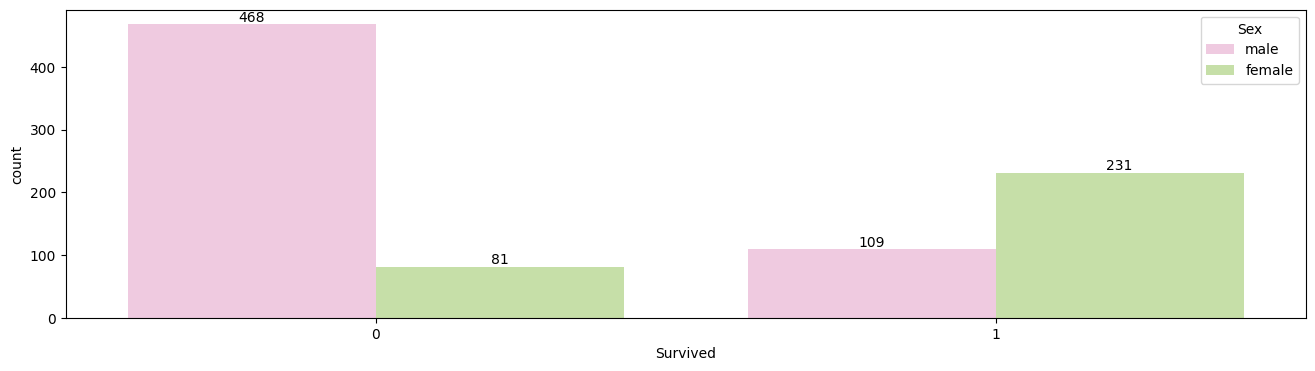

In [38]:
# pclass distribution       

plt.figure(figsize=(16,4))

a=sns.countplot(data=df,x="Survived",hue="Sex",palette="PiYG")

for container in a.containers:
    a.bar_label(container)

plt.show()

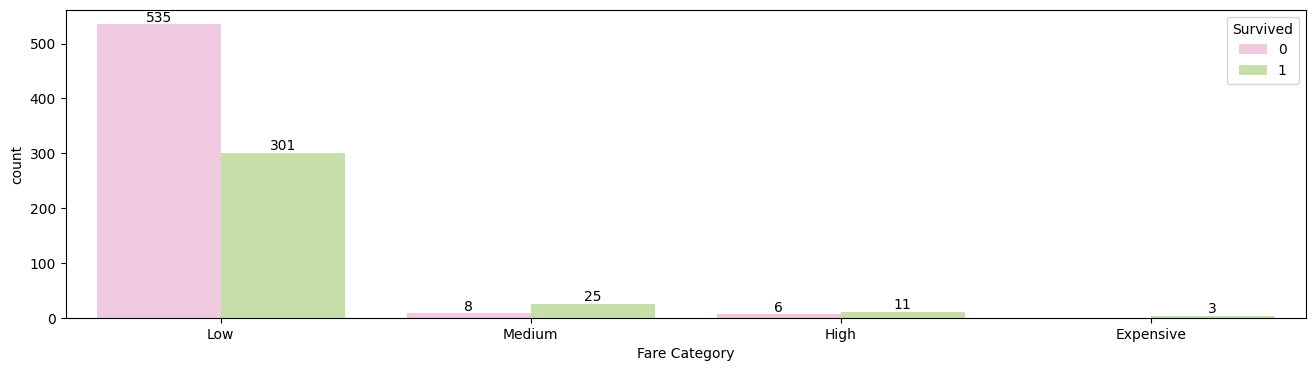

In [39]:
plt.figure(figsize=(16,4))

a=sns.countplot(data=df,x="Fare Category",hue="Survived",palette="PiYG")

for container in a.containers:
    a.bar_label(container)

plt.show()

---

In [40]:
#shape

df.shape

(889, 7)

In [41]:
# defining x and y

x=df.drop("Survived",axis=1)

In [42]:
y=df.Survived

In [43]:
x[:2]

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,male,S,Youth,Low,1
1,1,female,C,Adult,Low,1


In [44]:
y[:1]

0    0
Name: Survived, dtype: int64

In [45]:
x.shape

(889, 6)

In [46]:
y.shape

(889,)

---

In [47]:
# Encoding

from sklearn.preprocessing import LabelEncoder

In [48]:
le=LabelEncoder()

In [49]:
#columns
x[:2]

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,male,S,Youth,Low,1
1,1,female,C,Adult,Low,1


In [50]:
#apply
for col in x.select_dtypes(include=['object','category']).columns:
    x[col]=le.fit_transform(x[col])

In [51]:
x[:2]

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,1,2,3,2,1
1,1,0,0,0,2,1


In [52]:
x.dtypes

Pclass           int64
Sex              int64
Embarked         int64
Age Category     int64
Fare Category    int64
Family           int64
dtype: object

In [53]:
y.dtypes

dtype('int64')

---

In [54]:
#train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [55]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((711, 6), (178, 6), (711,), (178,))

In [56]:
# model 

from sklearn.tree import DecisionTreeClassifier

In [57]:
tree=DecisionTreeClassifier()

In [58]:
tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [59]:
#training accurscy
tree.score(x_train,y_train)

0.8663853727144867

In [60]:
#testing accuracy
tree.score(x_test,y_test)

0.8314606741573034

In [61]:
# confusion matrix

from sklearn.metrics import confusion_matrix

y_pred=tree.predict(x_test)

cm=confusion_matrix(y_test,y_pred)

cm

array([[96, 13],
       [17, 52]])

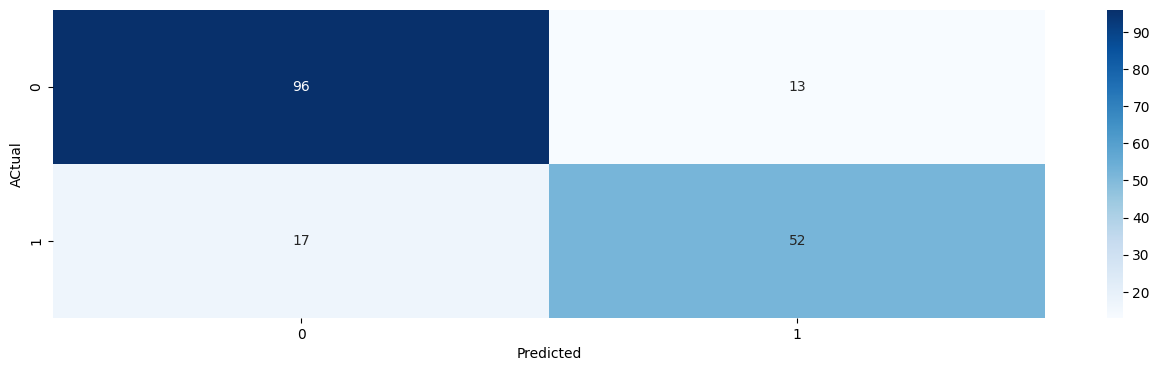

In [62]:
plt.figure(figsize=(16,4))

sns.heatmap(cm,annot=True,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("ACtual")
plt.show()

In [63]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       109
           1       0.80      0.75      0.78        69

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178



---

STREAMLIT

In [64]:
from joblib import dump

In [65]:
dump(tree,"tree.joblib")

['tree.joblib']

In [66]:
dump(x.columns,"columns.joblib")

['columns.joblib']

In [67]:
dump(x,"data.joblib")

['data.joblib']